# Aplicações de Machine Learning

## Treinamento dos modelos

Vamos utilizar 2 tipos de algoritmos de aprendizado de máquinas para comparar qual é o melhor modelo para esse problema de predição de churn.

- Árvore de decisão
- LightGBM

Faremos primeiro um treinamento básico, só para ver performance dos modelos para então entrarmos na parte de otimização de parâmetros. 

Para podermos comparar esses modelos, irei observarei métricas como:

### Precisão
<div align="center">


$ Precisão = \frac{VP}{VP + FP}$

</div>  

Onde temos que: 

- VP: Verdadeiros Positivos
- FP: Falsos Positivos

### Recall
<div align="center">

$ Recall = \frac{VP}{VP + FN}$

</div>  

Onde temos que:

- VP: Verdadeiros Positivos
- FN: Falsos Negativos

### F1-Score
<div align="center">

$ F1-Score = 2*\frac{Precisão*Recall}{Precisão + Recall} = \frac{2*VP}{2*VP + FP + FN}$

</div>  

Onde temos que:

- VP: Verdadeiros Positivos
- FP: Falsos Positivos
- FN: Falsos Negativos

E também veremos como se comporta a curva ROC e a área AUC desses modelos.

## Importando as bibliotecas para esse estudo

In [44]:
import lightgbm as lgb
import mlflow
import sklearn
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score, classification_report, auc, roc_curve
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from pathlib import Path
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import shap

## Vamos utilizar o MLflow para monitoramento e versionamento dos modelos que serão testados no processo de modelagem

In [2]:
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment(experiment_id="1")

<Experiment: artifact_location='file:C:/Users/breno/VSCode/mirante_teste', creation_time=1789325435124, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789325435124, lifecycle_stage='active', name='churn', tags={}, trace_location=None, workspace='default'>

## Importando a tabela

In [3]:
df = pd.read_excel('/Users/breno/VSCode/Python/Testes/MiranteTeste/data/raw/telco_customer_churn.xlsx')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3325-['N' 'S' 'A' 'U' 'G'],Female,0,Yes,No,61,Yes,No,Fiber optic,No internet service,...,No internet service,No,No,No,Month-to-month,Yes,Mailed check,82.76,5045.65,No
1,3329-['L' 'E' 'Q' 'M' 'H'],Male,0,Yes,No,8,No,No phone service,Fiber optic,No,...,No,Yes,No,No,Month-to-month,Yes,Electronic check,56.44,445.25,Yes
2,6955-['P' 'W' 'Q' 'D' 'X'],Male,0,Yes,No,41,Yes,No,DSL,No,...,No,No,Yes,No,Two year,No,Mailed check,97.57,3995.44,Yes
3,1409-['S' 'L' 'G' 'M' 'D'],Male,1,Yes,No,46,Yes,No,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),110.33,5087.22,No
4,9364-['M' 'J' 'O' 'G' 'Z'],Female,0,Yes,No,33,Yes,No,DSL,No,...,No internet service,No,Yes,No,Two year,Yes,Credit card (automatic),63.35,2101.75,No


In [4]:
df['Churn'] = df['Churn'].str.strip().map({"No": 0, "Yes": 1})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3325-['N' 'S' 'A' 'U' 'G'],Female,0,Yes,No,61,Yes,No,Fiber optic,No internet service,...,No internet service,No,No,No,Month-to-month,Yes,Mailed check,82.76,5045.65,0
1,3329-['L' 'E' 'Q' 'M' 'H'],Male,0,Yes,No,8,No,No phone service,Fiber optic,No,...,No,Yes,No,No,Month-to-month,Yes,Electronic check,56.44,445.25,1
2,6955-['P' 'W' 'Q' 'D' 'X'],Male,0,Yes,No,41,Yes,No,DSL,No,...,No,No,Yes,No,Two year,No,Mailed check,97.57,3995.44,1
3,1409-['S' 'L' 'G' 'M' 'D'],Male,1,Yes,No,46,Yes,No,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),110.33,5087.22,0
4,9364-['M' 'J' 'O' 'G' 'Z'],Female,0,Yes,No,33,Yes,No,DSL,No,...,No internet service,No,Yes,No,Two year,Yes,Credit card (automatic),63.35,2101.75,0


In [5]:
df = df.drop('customerID', axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,61,Yes,No,Fiber optic,No internet service,No,No internet service,No,No,No,Month-to-month,Yes,Mailed check,82.76,5045.65,0
1,Male,0,Yes,No,8,No,No phone service,Fiber optic,No,Yes,No,Yes,No,No,Month-to-month,Yes,Electronic check,56.44,445.25,1
2,Male,0,Yes,No,41,Yes,No,DSL,No,No,No,No,Yes,No,Two year,No,Mailed check,97.57,3995.44,1
3,Male,1,Yes,No,46,Yes,No,DSL,No,No internet service,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),110.33,5087.22,0
4,Female,0,Yes,No,33,Yes,No,DSL,No,No,No internet service,No,Yes,No,Two year,Yes,Credit card (automatic),63.35,2101.75,0


In [6]:
servicos = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['qtd_servicos'] = df[servicos].apply(
    lambda col: col.map(lambda x: 0 if x in ['No', 'No internet service', 'No phone service'] else 1)
).sum(axis=1)
df = df.drop(servicos, axis = 1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,qtd_servicos
0,Female,0,Yes,No,61,Month-to-month,Yes,Mailed check,82.76,5045.65,0,2
1,Male,0,Yes,No,8,Month-to-month,Yes,Electronic check,56.44,445.25,1,3
2,Male,0,Yes,No,41,Two year,No,Mailed check,97.57,3995.44,1,3
3,Male,1,Yes,No,46,Month-to-month,Yes,Bank transfer (automatic),110.33,5087.22,0,4
4,Female,0,Yes,No,33,Two year,Yes,Credit card (automatic),63.35,2101.75,0,3


In [7]:
df = pd.get_dummies(df, drop_first=True, dtype='int')
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,qtd_servicos,gender_Male,Partner_Yes,Dependents_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,61,82.76,5045.65,0,2,0,1,0,0,0,1,0,0,1
1,0,8,56.44,445.25,1,3,1,1,0,0,0,1,0,1,0
2,0,41,97.57,3995.44,1,3,1,1,0,0,1,0,0,0,1
3,1,46,110.33,5087.22,0,4,1,1,0,0,0,1,0,0,0
4,0,33,63.35,2101.75,0,3,0,1,0,0,1,1,1,0,0


In [8]:
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'qtd_servicos', 'gender_Male', 'Partner_Yes', 'Dependents_Yes',
       'Contract_One_year', 'Contract_Two_year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit_card_(automatic)',
       'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check'],
      dtype='object')

## Vamos começar divindo a tabela em treino e teste

In [9]:
y = df['Churn']
X = df.drop('Churn', axis=1)
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,qtd_servicos,gender_Male,Partner_Yes,Dependents_Yes,Contract_One_year,Contract_Two_year,PaperlessBilling_Yes,PaymentMethod_Credit_card_(automatic),PaymentMethod_Electronic_check,PaymentMethod_Mailed_check
0,0,61,82.76,5045.65,2,0,1,0,0,0,1,0,0,1
1,0,8,56.44,445.25,3,1,1,0,0,0,1,0,1,0
2,0,41,97.57,3995.44,3,1,1,0,0,1,0,0,0,1
3,1,46,110.33,5087.22,4,1,1,0,0,0,1,0,0,0
4,0,33,63.35,2101.75,3,0,1,0,0,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,16,28.55,440.23,5,1,1,0,1,0,0,0,0,1
7039,0,38,25.23,948.36,6,1,0,0,0,1,1,0,0,0
7040,0,32,34.00,1082.40,1,1,1,0,0,0,1,0,1,0
7041,0,27,114.83,3100.04,5,0,1,0,0,0,1,0,0,1


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

In [11]:
print(f'Base Treino: {y_train.shape[0]} Unid. | Tx. Target {100*y_train.mean():.2f}%')
print(f'Base Test: {y_test.shape[0]} Unid. | Tx. Target {100*y_test.mean():.2f}%')


Base Treino: 5634 Unid. | Tx. Target 35.16%
Base Test: 1409 Unid. | Tx. Target 35.13%


### Treino dos algoritmos


### Árvore de decisão


In [12]:
arvore_decisao = DecisionTreeClassifier()

In [13]:
arvore_decisao.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
y_probab_tree = arvore_decisao.predict_proba(X_test)[:,1]

In [15]:
teste_tree = pd.DataFrame({'Churn': y_test,
                           'Probabilidade': y_probab_tree})

teste_tree.head()

,Churn,Probabilidade
6537,0,1.0
5299,0,0.0
3876,0,1.0
712,0,0.0
6795,1,0.0


In [16]:
metricas_tree = teste_tree.groupby('Churn')['Probabilidade'].mean()
metricas_tree

Churn
0    0.368709
1    0.402020
Name: Probabilidade, dtype: float64

In [17]:
y_pred_tree = (y_probab_tree >= metricas_tree[1]).astype(int)
y_pred_tree

array([1, 0, 1, ..., 0, 1, 0], shape=(1409,))

In [18]:
print(f'Precisão: {precision_score(y_test, y_pred_tree):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_tree):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred_tree):.4f}')
print(f'ROC: {roc_auc_score(y_test, y_probab_tree):.4f}')


Precisão: 0.3713
Recall: 0.4020
F1 Score: 0.3860
ROC: 0.5167


### Gráfico da curva ROC

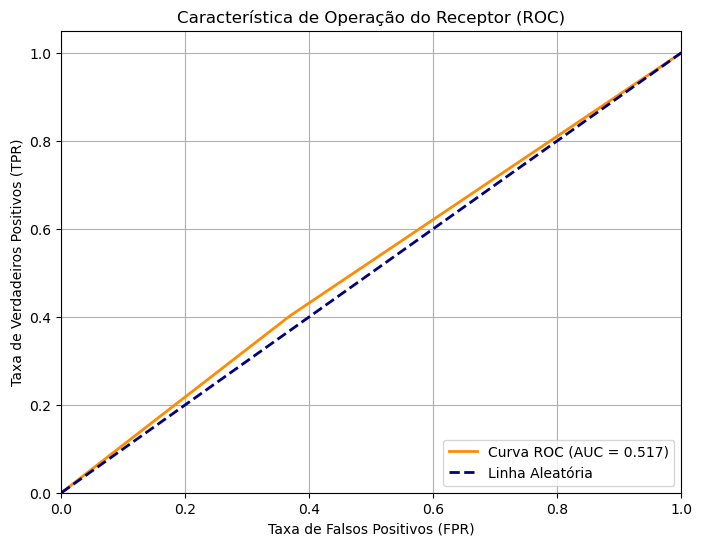

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_probab_tree)
auc_score = auc(fpr, tpr)  


plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"Curva ROC (AUC = {auc_score:.3f})",
)
plt.plot(
    [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Linha Aleatória"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Característica de Operação do Receptor (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### LightGBM

In [20]:
light = lgb.LGBMClassifier()

In [21]:
light.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1981, number of negative: 3653
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 613
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.351615 -> initscore=-0.611947
[LightGBM] [Info] Start training from score -0.611947


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [22]:
y_probab_light = light.predict_proba(X_test)[:,1]

In [23]:
teste_light = pd.DataFrame({'Churn': y_test,
                      'Probabilidade': y_probab_light})

teste_light

,Churn,Probabilidade
6537,0,0.179725
5299,0,0.149988
3876,0,0.510734
712,0,0.371192
6795,1,0.333760
...,...,...
1422,0,0.092241
4500,0,0.363376
4439,1,0.548246
6943,0,0.336829


In [ ]:
metricas_light = teste_light.groupby('Churn')['Probabilidade'].mean()


Churn
0    0.338638
1    0.385021
Name: Probabilidade, dtype: float64

In [25]:
y_pred_light = (y_probab_light >= metricas_light[1]).astype(int)

In [26]:
print(f'Precisão: {precision_score(y_test, y_pred_light):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_light):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred_light):.4f}')
print(f'ROC: {roc_auc_score(y_test, y_probab_light):.4f}')

Precisão: 0.4171
Recall: 0.5232
F1 Score: 0.4642
ROC: 0.5908


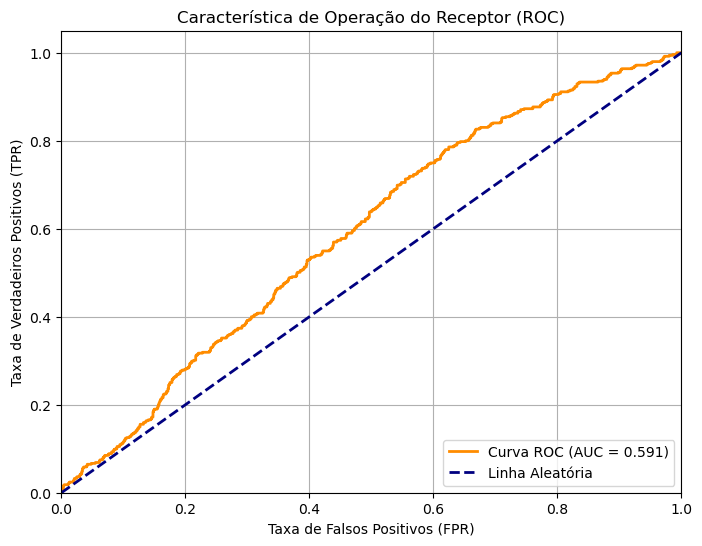

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_probab_light)
auc_score = auc(fpr, tpr)  


plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"Curva ROC (AUC = {auc_score:.3f})",
)
plt.plot(
    [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Linha Aleatória"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Característica de Operação do Receptor (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Após o treinamento, temos que o melhor modelo é dado pelo LightGBM.

### Vamos fazer a otimização dos parâmetros utilizando o GridSearch

In [30]:
modelo = {
    "Light": {
        "model": lgb.LGBMClassifier(),
        "params": {
            'learning_rate': [0.01, 0.05, 0.1],
            'n_estimators': [300, 500,900],
            'max_depth': [3,5,6,8],
            'subsample': [0.5, 0.75, 1]
        }
    }
}

In [ ]:
for nome, info in modelo.items():
    with mlflow.start_run(run_name=nome):

        grid = GridSearchCV(
            estimator=info['model'],
            param_grid=info['params'],
            cv=3,
            verbose=4,
            scoring="roc_auc"
        )

        mlflow.lightgbm.autolog()

        grid.fit(X_train, y_train)

        #melhor modelo
        best_model = grid.best_estimator_
        # melhor modelo
        pred = best_model.predict(X_test)
        probabilidade_teste = best_model.predict_proba(X_test)[:,1]
        
        
        # =======================
        # Predições teste
        # =======================

        y_test_pred = (probabilidade_teste >= metricas_light[1]).astype(int)

        precisao_teste = precision_score(y_test, y_test_pred)
        recall_teste = recall_score(y_test, y_test_pred)
        f1_teste = f1_score(y_test, y_test_pred)
        roc_auc_teste = roc_auc_score(y_test, probabilidade_teste)
        # registro de parametros
        mlflow.log_params(grid.best_params_)

        # registro de metricas
        mlflow.log_metrics({
            "Precisao_teste": precisao_teste,
            "Recall_teste": recall_teste,
            "F1_teste": f1_teste,
            "Curva_roc_teste": roc_auc_teste
        })

        print(f'{nome} finalizado!')


In [32]:
best_model.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.01,
 'max_depth': 3,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 300,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': None,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 0.5,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [34]:
print(f'Precisão: {precisao_teste:.4f}')
print(f'Recall: {recall_teste:.4f}')
print(f'F1 Score: {f1_teste:.4f}')
print(f'Curva ROC: {roc_auc_teste:.4f}')

Precisão: 0.4300
Recall: 0.7192
F1 Score: 0.5382
Curva ROC: 0.6272


In [41]:
best_model = grid.best_estimator_
best_model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,3
,learning_rate,0.01
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


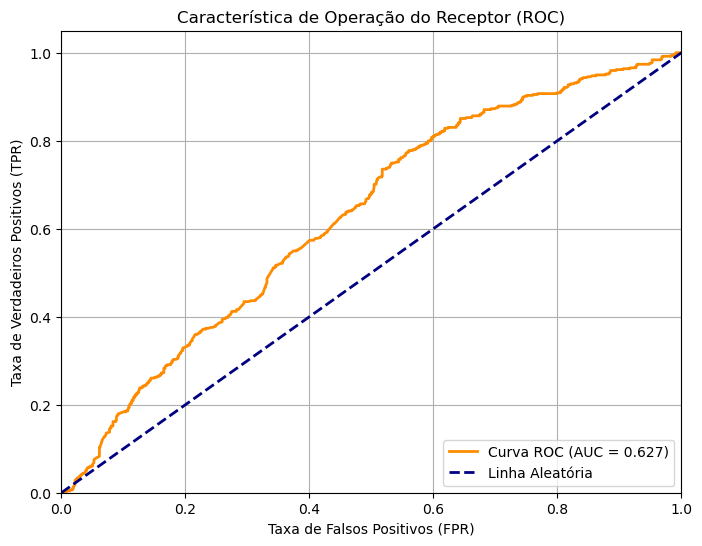

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, probabilidade_teste)
auc_score = auc(fpr, tpr)  


plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"Curva ROC (AUC = {auc_score:.3f})",
)
plt.plot(
    [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Linha Aleatória"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Característica de Operação do Receptor (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Interpretação das features

### SHAP

In [47]:
explicacao = shap.TreeExplainer(best_model)
shap_valores = explicacao(X_test)

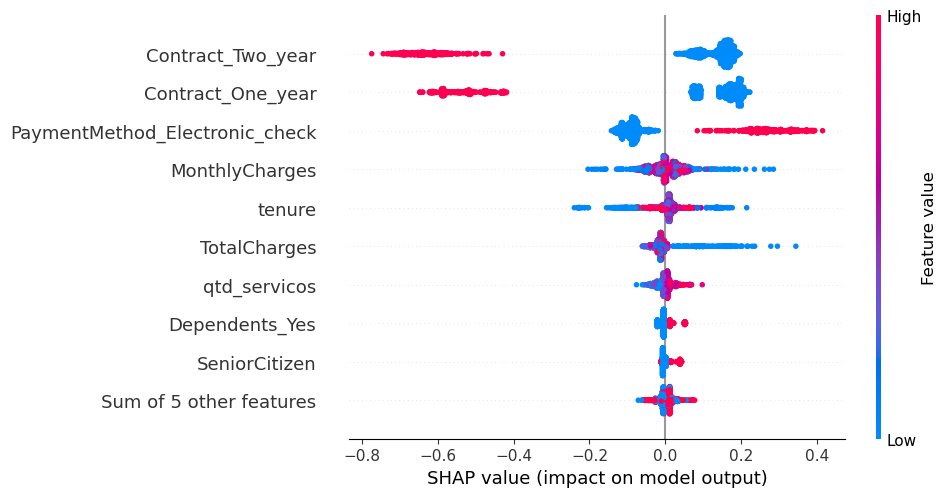

In [52]:
shap.plots.beeswarm(shap_valores)

Interpretação do SHAP: A análise dos valores SHAP mostra que o tipo de contrato é o principal fator utilizado pelo modelo para discriminar clientes com maior ou menor risco de churn.

Clientes com contratos de um ou dois anos apresentam valores SHAP predominantemente negativos, indicando que essas modalidades reduzem a previsão de churn. Em contrapartida, o uso de Electronic check como método de pagamento apresenta valores SHAP positivos quando presente, contribuindo para aumentar a previsão de churn.

Variáveis como *MonthlyCharges*, *tenure* e *TotalCharges* também influenciam as previsões, porém com magnitude significativamente menor. Esses resultados sugerem que clientes sem contratos de longo prazo e que utilizam pagamento via *Electronic check* representam grupos de maior atenção para estratégias de retenção. 

Os valores SHAP representam o comportamento aprendido pelo modelo e não devem ser interpretados como relações causais.